# Basic Time Series Forecasting Techniques (Kỹ thuật dự báo chuỗi thời gian cơ bản)




## Giới thiệu



Forecasting (Dự báo) là một lĩnh vực rộng với nhiều ứng dụng trong hầu hết các ngành. Do đó, phạm vi các Forecasting Model (Mô hình dự báo) cũng rất lớn với mỗi Model (Mô hình) có ưu và nhược điểm riêng.

Trong bài viết này, tôi muốn đề cập đến một số Forecasting Model (Mô hình dự báo) cơ bản và đơn giản. Mặc dù đơn giản, các Model (Mô hình) này có thể cung cấp kết quả tốt trong thực tế và cung cấp cơ sở tốt để lặp lại.


## Average Forecast (Dự báo trung bình)



Model (Mô hình) đầu tiên chúng ta sẽ xem xét là Average Forecast (Dự báo trung bình). Model (Mô hình) này chỉ đơn giản giả định rằng tất cả các giá trị trong tương lai bằng Mean (Trung bình) của tất cả các Observation (Quan sát) trước đó:


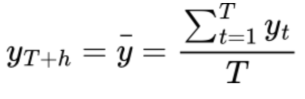

Trong đó h là Time-Step (Bước thời gian) trong tương lai mà chúng ta đang dự báo, T là độ dài của Time Series (Chuỗi thời gian), y_t là giá trị quan sát được tại thời điểm t và y_bar là Mean (Trung bình) của các giá trị quan sát được. Đối với Model (Mô hình) này, chúng ta phải có một số dữ liệu quá khứ có sẵn để tính toán Forecast (Dự báo).



In [ ]:
# Import các thư viện
import plotly.graph_objects as go
import pandas as pd

# Đọc dữ liệu
data = pd.read_csv('AirPassengers.csv')
data['Month'] = pd.to_datetime(data['Month'])

# Chia train và test
train = data.iloc[:-int(len(data) * 0.2)]
test = data.iloc[-int(len(data) * 0.2):]


def plot_func(forecast, title):
    """Hàm để vẽ biểu đồ các forecast."""
    fig = go.Figure()
    fig.add_trace(go.Scatter(x=train['Month'], y=train['#Passengers'], name='Train'))
    fig.add_trace(go.Scatter(x=test['Month'], y=forecast, name='Test'))
    fig.update_layout(template="simple_white", font=dict(size=18), title_text=title,
                      width=650, title_x=0.5, height=400, xaxis_title='Date',
                      yaxis_title='Passenger Volume')

    return fig.show()


In [ ]:
# Average forecast
test['mean_forecast'] = train['#Passengers'].mean()
plot_func(test['mean_forecast'], 'Average Forecast')


/var/folders/lv/t3hqq91524b1nlzy1_jp_z8c0000gn/T/ipykernel_2634/2790250637.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Naive Forecasting (Dự báo ngây thơ)



Model (Mô hình) thứ hai, Naive Forecasting (Dự báo ngây thơ), là đặt Forecast (Dự báo) trong tương lai bằng giá trị quan sát được gần đây nhất:


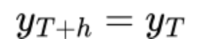

Model (Mô hình) này được coi là Benchmark (Điểm chuẩn) cho bất kỳ Forecast (Dự báo) nào và thường được sử dụng để mô hình hóa dữ liệu thị trường chứng khoán và tài chính do tính chất thất thường của nó. Naive Model (Mô hình ngây thơ) cũng có thể được gọi là Random-Walk-Without-Drift Model (Mô hình bước đi ngẫu nhiên không có drift).


In [ ]:
# Naive forecast
test['naive_forecast'] = train['#Passengers'].iloc[-1]
plot_func(test['naive_forecast'], 'Naive Forecast')


/var/folders/lv/t3hqq91524b1nlzy1_jp_z8c0000gn/T/ipykernel_2634/1144585780.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



## Seasonal Naive Forecasting (Dự báo ngây thơ theo mùa)


Method (Phương pháp) thứ ba là mở rộng của Naive Method (Phương pháp ngây thơ), nhưng lần này Forecast (Dự báo) bằng giá trị quan sát được gần đây nhất trong cùng mùa. Do đó, nó được gọi là Seasonal Naive Model (Mô hình ngây thơ theo mùa). Ví dụ, Forecast (Dự báo) cho quý một tiếp theo bằng giá trị quý một của năm trước. Model (Mô hình) này hữu ích khi chúng ta có Seasonal Variation (Biến động theo mùa) rõ ràng và lớn trong Time Series (Chuỗi thời gian) của chúng ta.


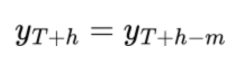

Trong đó m là Seasonality (Tính mùa vụ) của dữ liệu. Vì vậy, đối với dữ liệu hàng tháng với Seasonality (Tính mùa vụ) hàng năm m=12, dữ liệu hàng quý sẽ có m=4 và dữ liệu hàng tuần sẽ có m=52.


In [ ]:
# Seasonal naive forecast
train['month_number'] = pd.DatetimeIndex(train['Month']).month
test['month_number'] = pd.DatetimeIndex(test['Month']).month

snaive_fc = []
for row_idx, row in test.iterrows():
    month = row['month_number']
    forecast = train['#Passengers'] .loc[train['month_number'] == month].iloc[-1]
    snaive_fc.append(forecast)

plot_func(snaive_fc, 'Seasonal Naive Forecast')


/var/folders/lv/t3hqq91524b1nlzy1_jp_z8c0000gn/T/ipykernel_2634/294302301.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/lv/t3hqq91524b1nlzy1_jp_z8c0000gn/T/ipykernel_2634/294302301.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



Vì Model (Mô hình) của chúng ta có Seasonality Component (Thành phần mùa vụ) khá rõ ràng và lớn, Seasonal Naive Model (Mô hình ngây thơ theo mùa) đang hoạt động khá tốt. Tuy nhiên, nó không nắm bắt đầy đủ Trend (Xu hướng) của dữ liệu vì chúng ta kỳ vọng khối lượng hành khách tăng theo thời gian.


## Drift Model (Mô hình trượt)



Model (Mô hình) cuối cùng chúng ta sẽ xem xét là Drift Model (Mô hình trượt). Đây cũng là một mở rộng của Naive Forecast (Dự báo ngây thơ) trong đó chúng ta để Prediction (Dự đoán) tăng hoặc giảm tuyến tính theo thời gian như một hàm của Time Step (Bước thời gian), h, được chia tỷ lệ bởi Average Historical Trend (Xu hướng lịch sử trung bình):


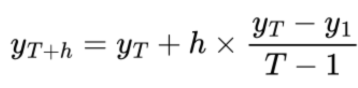

Về cơ bản đây chỉ là việc vẽ một đường thẳng từ điểm đầu tiên đến điểm cuối cùng và mở rộng nó về phía trước theo thời gian. Tuy nhiên, đây là nơi vấn đề nằm vì Model (Mô hình) sẽ luôn tăng hoặc giảm theo thời gian, điều này thường không xảy ra trong các tình huống thực tế.


In [ ]:
# Drift forecast
constant = (train['#Passengers'].iloc[-1] - train['#Passengers'].iloc[0])/(len(train)-1)
test['h'] = range(len(test))
test['drift_forecast'] = train['#Passengers'].iloc[-1] + test['h']*constant

plot_func(test['drift_forecast'], 'Drift Forecast')
